# Assignment 1 — Regression, Optimization, and Generalization

This assignment studies how **data preparation, optimization, model complexity, and validation** affect a regression model.

The goal is not only to obtain a low prediction error, but to understand **why a model behaves the way it does**. You will compare different ways of solving the same regression problem, study how optimization choices such as the batch size and learning rate affect convergence, and then investigate what happens when the model itself becomes more flexible.

**Structure:**
- **Parts 1–5:** one connected Spotify regression case study.
- **Part 6:** an independent California Housing regression exercise.
- **Optional question:** a theoretical exercise on uniform convergence.

The assignment progresses from a direct least-squares solution to full-batch gradient descent, mini-batch and stochastic methods, learning-rate selection, and nonlinear regression. Along the way, you will use training and validation performance to distinguish **optimization behavior** from **generalization behavior**.

By the end of the assignment, you should be able to connect the computational experiments to the underlying theory and explain the main conclusions using clear plots, tables, and mathematical arguments.

**Important implementation rule:** In Parts 1–5, implement the required learning procedures yourself rather than replacing them with ready-made regression or optimization estimators. Use only the low-level operations and specific helper routines explicitly permitted in each part.


**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the MIE370 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on projects or assessments will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:

Full Name: Angeline Wong  

Student ID: 1010918027

UTorID: wonga128

**Three submission files are required:**

For submitting this project, three files must be submitted on Quercus by the project deadline:

1) The complete Jupyter file containing all code and comments with outputs (in .ipynb format) (that completely compiles on Google colab without any errors regardless of the computer used.)

2) A self-contained and complete HTML printout of the same Jupyter file with all the output printed as well as all the code, text cells, comments, and figures.

3) Appendix pdf file of all prompts and all responses for all interactions you have had regarding this project with any AI assistant tool (Chat GPT etc.). If you do not use any AI assistant tool at all, this appendix pdf file is not needed.

**Policy regarding the use of AI assistant tools**

If you use a generative AI tool (e.g., ChatGPT, GitHub Copilot, or any other similar tool) to get ideas and/or partial answers for projects or assignments or to generate any code and/or text, you must declare in your submission the tools that you have used and describe the usage, and include in your submission an appendix that captures all the interactions (prompts and responses).

You will not be penalized for the declared use of such AI assistant tools, and the grading decisions will be based on your original contributions as well as the efforts that you make to check and/or correct the answers provided by the tool. Students are ultimately accountable for the work they submit. Failure to fully declare the use of this tool will be considered "unauthorized assistance" and will have consequences (See B.I. of the [U of T CODE OF BEHAVIOUR ON ACADEMIC MATTERS](https://governingcouncil.utoronto.ca/secretariat/policies/code-behaviour-academic-matters-july-1-2019))

##**Marking Scheme:**

This project is worth **8 percent** of your final grade.

The required questions are graded out of **100 marks**. The optional mathematical question is worth up to **10 additional bonus marks** and is not included in the 100-mark total.

Draw a plot or table where necessary to summarize your findings.

**Practice Vectorized coding**: If you need to write a loop in your solution, think about how you can implement the same functionality with vectorized operations. Try to avoid loops as much as possible (in some cases, loops are inevitable).




### How to obtain an **HTML** file from an **IPYNB** file

1. Download the IPYNB file of your complete project: `File -> Download .ipynb`

2. Click on the Files icon on the far left menu of a new Colab session

3. Select & upload your `.ipynb` file you just downloaded, and then copy its path (right click) (you might need to hit the Refresh button before your file shows up)


4. Replace XXXX with the copied path and then execute the following in a Colab cell:
```
%%shell
jupyter nbconvert --to html XXXX
```

5. An HTML version of your notebook will appear in the Colab session files and you can download it.

6. Submit **both** <font color='red'>`HTML` and `IPYNB`</font>  files on Quercus (before the deadline) for grading.



More info on coverting IPYNB to HTML: https://stackoverflow.com/a/64487858



## Working in VS Code

Install the required packages if needed:

```bash
python3 -m pip install numpy pandas scipy matplotlib scikit-learn ipykernel nbconvert
```

Open the notebook, select the correct Python kernel, and run the setup cell before starting the assignment.


# Assignment Roadmap

| Part | Dataset | Main topic | Marks |
|---|---|---|---:|
| **1** | Spotify | Data preparation | 12 |
| **2** | Spotify | Direct least squares | 12 |
| **3** | Spotify | Full-batch gradient descent | 15 |
| **4** | Spotify | Mini-batch and stochastic gradient descent | 24 |
| **5** | Spotify | Learning-rate selection | 20 |
| **6** | California Housing | Polynomial features and regularization | 17 |

Parts 1–5 form one connected Spotify case study. Part 6 is independent.

Required total: **100 marks**. The optional mathematical question is worth up to **10 additional bonus marks**.

**Implementation requirement for Parts 1–5:** You are expected to implement the learning procedures in detail yourself rather than calling ready-made regression or optimization estimators. Low-level NumPy operations are allowed, and any explicitly permitted routine in the instructions may be used (for example, `np.linalg.lstsq` where requested and `OneHotEncoder` for preprocessing). Do **not** replace the required GD, mini-batch/SGD, learning-rate experiments with built-in learning algorithms from libraries such as `sklearn`.

### Setup

Run the next code cell before Part 1. It imports the required libraries and defines the dataset-download helper used later.

If you restart the kernel, run the setup cell again before continuing.


In [14]:
from pathlib import Path
from urllib.request import urlretrieve
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)
print("Dataset folder:", DATA_DIR.resolve())

def download_dataset(url, filename):
    destination = DATA_DIR / filename
    if not destination.exists():
        temporary = destination.with_suffix(destination.suffix + ".part")
        try:
            urlretrieve(url, temporary)
            temporary.replace(destination)
        finally:
            temporary.unlink(missing_ok=True)
    return destination

Dataset folder: C:\Users\home\Downloads\MIE370_Assignment_1_Spotify_Popularity\data


# Case Study A — Can Sound Predict Popularity?
### Spotify Tracks · used in Parts 1–5

The first five parts use the **Spotify Tracks dataset by Maharshi Pandya**, containing roughly 114,000 raw track records and 21 CSV columns.

> **Prediction task:** estimate the recorded `popularity` score from a song's audio, genre, and basic categorical characteristics.

The target `popularity` is an integer from 0 to 100, but this is treated as a **regression problem**, so predictions may be decimal values. Keep raw predictions when computing RMSE; do not round or clip them in the main comparison.

### Numerical audio features

| Feature | Description |
|---|---|
| `duration_ms` | Track duration in milliseconds |
| `danceability` | Audio-based danceability measure |
| `energy` | Perceived intensity and activity |
| `loudness` | Overall loudness in decibels |
| `speechiness` | Presence of spoken words |
| `acousticness` | Acoustic character |
| `instrumentalness` | Instrumental character |
| `liveness` | Evidence of a live audience |
| `valence` | Musical positiveness |
| `tempo` | Estimated beats per minute |

### Categorical and binary inputs

| Feature | Meaning | Example values |
|---|---|---|
| `track_genre` | Track genre | `pop`, `rock`, `jazz`, `acoustic`, ... |
| `key` | Musical key category | `0`, `1`, `2`, ..., `11` |
| `time_signature` | Time-signature category | `3`, `4`, `5`, ... |
| `mode` | Major/minor mode | `0`, `1` |
| `explicit` | Explicit-content flag | `False`, `True` |

### Variables used for prediction

Use the 15 input variables listed above as predictors.

The target variable is `popularity`. Any remaining columns in the dataset that are not listed above, such as `track_id`, `artists`, `album_name`, and `track_name`, are descriptive metadata and should be excluded from the predictor set. `track_id` should be used only to identify duplicate tracks during data cleaning and then filtered out.

> Although `key` and `time_signature` are stored as numbers, treat them as **categories**, not as continuous measurements.


## Part 1 — Getting Started: Build the Regression Dataset [12 marks]

**Goal:** Turn the raw Spotify table into a leakage-free numerical design matrix that every later Spotify experiment can reuse.

1. Run the supplied code to download the Spotify dataset. Read the CSV file into a Pandas DataFrame named `df` and print it. **[1]**
2. Prepare your dataset in the following order: **[9]**

   **(a)** Remove duplicate `track_id` rows (keep the first) and rows missing a selected input or `popularity`. Then randomly select **80,000 rows** using `sample(n=80000, random_state=7)`.

   Use 80,000 observations so that the computational differences between full-batch and mini-batch methods are easier to observe in the later GD/SGD experiments. The fixed `random_state` makes the selected subset reproducible.

   **(b)** Separate the 15 selected input features from the target, `popularity`.

   **(c)** Split the inputs and target together into 80% training and 20% validation using `train_test_split` with `random_state=7`. **[3 for (a)–(c)]**

   **(d)** The variables `track_genre`, `key`, and `time_signature` are **categorical**, so they must first be converted into a numerical representation before they can be used in linear regression.

   For this assignment, use **one-hot encoding**. This creates a separate 0/1 indicator column for each category, rather than assigning arbitrary numbers to the categories. Fit the encoder on the **training inputs only**, then use the same fitted encoder to transform both the training and validation sets. Keep `mode` as 0/1 and convert `explicit` from False/True to 0/1.

   If you are unfamiliar with one-hot encoding, look it up before implementing this step. You may use online documentation or tutorials to understand the idea and how `OneHotEncoder` works.

   **(e)** Standardize each input feature by subtracting its **training-set mean** and dividing by its **training-set standard deviation**. Use these same training-set values to standardize both the training and validation sets. **[4 for (d)–(e)]**

   **(f)** Insert a first column of all ones in both standardized input matrices. **[2]**
3. Explain why the ones column should be added after standardization. **[1]**
4. Suppose a categorical feature has three values, such as `rock`, `pop`, and `jazz`. Why would encoding them as `rock = 1`, `pop = 2`, and `jazz = 3` be potentially misleading in a linear regression model? In your answer, explain what numerical ordering or distance the model would incorrectly infer from these values. Then briefly explain how one-hot encoding avoids this problem and state one disadvantage of using one-hot encoding when a feature has many categories. **[1]**

**Important points:**

- **Standardize both the training and validation inputs**, but compute the mean and standard deviation using the **training set only**. Then use those same training-set values to transform both sets:

$$
X_{\mathrm{train}}^{\mathrm{std}}
=
\frac{X_{\mathrm{train}}-\mu_{\mathrm{train}}}
{\sigma_{\mathrm{train}}},
\qquad
X_{\mathrm{val}}^{\mathrm{std}}
=
\frac{X_{\mathrm{val}}-\mu_{\mathrm{train}}}
{\sigma_{\mathrm{train}}}.
$$

  Do **not** compute a separate mean or standard deviation from the validation set, since validation data should not influence the preprocessing learned from training data.

- You can use `OneHotEncoder` from `sklearn.preprocessing` to perform one-hot encoding of the categorical features. You may import it using:

```python
from sklearn.preprocessing import OneHotEncoder
```

  A suitable configuration for this assignment is:

```python
OneHotEncoder(handle_unknown="ignore", sparse_output=False)
```


### About the supplied code below

The code below prepares a few definitions that you will use in Part 1. It downloads the Spotify CSV and stores its location in `spotify_path`, and it specifies which columns should be treated as numerical, categorical, binary, and as the target variable.

Running the code cell below saves you from having to manually download the dataset or repeatedly type the feature names. Your work begins at `# YOUR CODE HERE`, where you should load the CSV using `spotify_path` and carry out the data preparation requested in Part 1.


In [15]:
SPOTIFY_URL = (
    "https://huggingface.co/datasets/maharshipandya/"
    "spotify-tracks-dataset/resolve/main/dataset.csv?download=true"
)
spotify_path = download_dataset(SPOTIFY_URL, "spotifyW_tracks.csv")

NUMERIC_FEATURES = [
    "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]
CATEGORICAL_FEATURES = ["track_genre", "key", "time_signature"]
BINARY_FEATURES = ["mode", "explicit"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
TARGET = "popularity"

# YOUR CODE HERE
# Question 1: Print and Run df
df = pd.read_csv(spotify_path)
print(df)

# Question 2: Prepare the dataset
# 2a)
df = df.drop_duplicates(subset=['track_id'], keep='first') 
drop_columns = FEATURES + [TARGET]
df = df.dropna(subset=drop_columns, how='any') 

df = df.sample(n=80000, random_state=7)

# 2b) (x, y)
features_df = df[FEATURES] # aka. x
target_df = df[TARGET] # aka. y

# 2c)
x_train, x_val, y_train, y_val = train_test_split(
    features_df, target_df, test_size=0.2, random_state=7
)

# 2d)
# Convert explicit's False/True to 0/1
x_train = x_train.copy() # added just incase of SettingWithCopyWarning
x_val = x_val.copy()
x_train['explicit'] = x_train['explicit'].astype(int)
x_val['explicit'] = x_val['explicit'].astype(int)

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_train_array = encoder.fit_transform(x_train[CATEGORICAL_FEATURES]) # trading inputs only
encoded_val_array = encoder.transform(x_val[CATEGORICAL_FEATURES]) # trading inputs only

# Add 0/1 for each categorical feature into df
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_FEATURES)
x_train_encoded_df = pd.DataFrame(encoded_train_array, columns=encoded_cols, index=x_train.index)
x_val_encoded_df = pd.DataFrame(encoded_val_array, columns=encoded_cols, index=x_val.index)

# Delete original categorical features 
x_train_numeric = x_train.drop(columns=CATEGORICAL_FEATURES)
x_val_numeric = x_val.drop(columns=CATEGORICAL_FEATURES)

x_train = pd.concat([x_train_numeric, x_train_encoded_df], axis=1) # Concat horizontally
x_val = pd.concat([x_val_numeric, x_val_encoded_df], axis=1) # Concat horizontally

# 2e)
train_mean = x_train.mean()
train_std = x_train.std()
x_train_stand = (x_train - train_mean) / train_std
x_val_stand = (x_val - train_mean) / train_std

# 2f) 
x_train_stand.insert(0, 'b', 1)
x_val_stand.insert(0, 'b', 1)

"""
# 3. Explain why the ones column should be added after standardization.
The ones column represents the intercept term (aka the bias) in a linear regression model. 
It should be added after standardization because:
   1. It keeps the column as a true constant column of 1s, so the intercept (bias) is
      added directly to every prediction without being rescaled or shifted.
   2. It ensures that the standardization process does not alter the column into all zeros
      (aka. subtracting the mean of a constant column makes all the values 0) or cause an 
      undefined value (division by zero) during standardization.


# 4. Explain why adding numerics to values is misleading in a linear regression model.
Integer encoding categories using 1,2 and 3 are misleading because linear regression models
treats numeric inputs as continious values. This causes the model to assume these issues:
    1. Incorrect Ordering: Infers ranks as jazz (3) > pop (2) > rock (1) which is not true.
    2. Incorrect Distance: Infers that the distance between pop and rock is the same (2-1=1) 
       as the distance between jazz and pop (3-2=1) which is not true..

One-Hot encoding fixes this issue by creating independent binary columns for each category. This 
creates a more accurate representation of categorical data by removing any artificial mathematical
relationships or ordering between categories. Each category is treated as a separate entity, allowing 
the model to learn the unique impact of each category on the target variable without introducing bias 
or misleading assumptions.

One disadvantage of one-hot encoding is when the the number of categories get too large, the number
of features increase signigicantly, which leads to a high dimensionality problem. This problem consists
of having hundreds or thousands of binary columns resulting in a sparse matrix with mostly zeros. This
can lead to increased memory consumption, slower training times and potential overfitting.
"""

        Unnamed: 0                track_id                 artists  \
0                0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1                1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2                2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3                3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4                4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...            ...                     ...                     ...   
113995      113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996      113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997      113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998      113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999      113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                    

'\n# 3. Explain why the ones column should be added after standardization.\nThe ones column represents the intercept term (aka the bias) in a linear regression model. \nIt should be added after standardization because:\n   1. It keeps the column as a true constant column of 1s, so the intercept (bias) is\n      added directly to every prediction without being rescaled or shifted.\n   2. It ensures that the standardization process does not alter the column into all zeros\n      (aka. subtracting the mean of a constant column makes all the values 0) or cause an \n      undefined value (division by zero) during standardization.\n\n\n# 4. Explain why adding numerics to values is misleading in a linear regression model.\nInteger encoding categories using 1,2 and 3 are misleading because linear regression models\ntreats numeric inputs as continious values. This causes the model to assume these issues:\n    1. Incorrect Ordering: Infers ranks as jazz (3) > pop (2) > rock (1) which is not true

## Part 2 — Direct Least-Squares Reference [12 marks]

**Implementation note:** Use `np.linalg.lstsq` as requested here. Do not replace this part with a built-in regression estimator such as `LinearRegression`.

**Goal:** Establish the benchmark solution that later optimization methods will try to match.

Implement the direct solution of the linear regression problem on the training set. **[4]**

**Note:** Use `numpy.linalg.lstsq` to compute the direct least-squares solution. Unlike an explicit matrix inverse, this solver handles the redundant columns produced by keeping every one-hot category. Do not add regularization to this baseline.

**Do not use `numpy.linalg.inv`** (you can verify that the rank of the design matrix is smaller than its number of columns. Therefore, the design matrix is rank-deficient, and

$$
X^T X
$$

is singular. Consequently,

$$
(X^T X)^{-1}
$$

does not exist, and `numpy.linalg.inv` may raise an error).

Report the root-mean-square error (RMSE) for both the training and validation sets. **[2]**

You may use `mean_squared_error` from sklearn to compute RMSE. Report errors in popularity-score points.


In [16]:
# You may define a small RMSE helper if useful.
def calculate_rmse(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    return np.sqrt(np.mean((actual-predicted)**2))

# YOUR CODE HERE: direct least-squares fit and train/validation RMSE.
# Convert df to numpy arrays for lstsq calculation
X_train = x_train_stand.to_numpy(dtype=float)
X_val = x_val_stand.to_numpy(dtype=float)

# Use np.linalg.lstsq to compute the least-squares solution
w_ls, residuals, rank, sing_vals = np.linalg.lstsq(X_train, y_train.to_numpy(), rcond=None)
# w_ls: optimal weights, residuals: will be empty array if matrix has multicollinearity, 
# rank: rank of the matrix, sing_vals: singular values

print("Rank:", rank, "| Num. of columns:", X_train.shape[1]) # Adding this to check if rank < # of columns
# When printing result, 140 < 143 implying there are 3 redundant columns/features in the training set.

# Calculate predictions
y_train_pred = X_train @ w_ls
y_val_pred = X_val @ w_ls

# Calculate RMSE for training and validation sets
rmse_train = calculate_rmse(y_train, y_train_pred)
rmse_val = calculate_rmse(y_val, y_val_pred)

# Print Train and Validation RMSE
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")

Rank: 140 | Num. of columns: 143
Train RMSE: 16.8916
Validation RMSE: 16.6299


### Additional question — Interpreting the regression error **[2 marks]**

Using the training and validation RMSE values from the direct linear-regression model, answer the following:

**Question 1 — Interpret the error. [0.5]**  
Interpret the RMSE in the context of Spotify popularity scores. For example, what does a training RMSE of about 17.5 mean in practical terms?

**Question 2 — Model suitability and generalization. [1.5]**  
Compare the training and validation RMSE. Does an RMSE of this size, by itself, imply that linear regression is inappropriate? What do the size of the errors and the difference between them suggest about the model's generalization and possible limitations?


In [17]:
"""
# Question 1: Interpret the error.
RMSE calculates the average magnitude of how far off the model's predictions are from the actual values. In this case,
the Spotify popularity scores range from 0 to 100, so an RMSE of 16.89 (basically 17 points) means that on average,
the model's predictions are off by +/- 17 points from the actual popularity score. This is a relatively large error, as
it indicates the model only gives a rough estimate of the popularity score and is not very accurate.

# Question 2: Model suitability and generalization.
The training RMSE is 16.89 and the validation RMSE is 16.63, which are very close/similar to each other. This indicates
that the model is not overfitting since the model performs similarly on both the training and validation datasets. However,
even if the model is not overfitting, the RMSE for both are relatively high which could imply that the model is underfitting.

Having an RMSE of this size does not imply that linear regression is inappropriate for this problem. It's possible that the
available features don't contain enough information to predict popularity (e.g. artist fame and marketing aren't included),
or that the relationship between the features and popularity is not linear. Using a non-linear model or adding more relevant
features could potentially improve the model's performance.
"""

"\n# Question 1: Interpret the error.\nRMSE calculates the average magnitude of how far off the model's predictions are from the actual values. In this case,\nthe Spotify popularity scores range from 0 to 100, so an RMSE of 16.89 (basically 17 points) means that on average,\nthe model's predictions are off by +/- 17 points from the actual popularity score. This is a relatively large error, as\nit indicates the model only gives a rough estimate of the popularity score and is not very accurate.\n\n# Question 2: Model suitability and generalization.\nThe training RMSE is 16.89 and the validation RMSE is 16.63, which are very close/similar to each other. This indicates\nthat the model is not overfitting since the model performs similarly on both the training and validation datasets. However,\neven if the model is not overfitting, the RMSE for both are relatively high which could imply that the model is underfitting.\n\nHaving an RMSE of this size does not imply that linear regression is in

### Additional question — Which audio characteristics are most associated with popularity? **[4 marks]**

The ten numerical audio features were standardized before fitting the regression model. Therefore, their regression coefficients can be compared on a common scale.

1. Write Python code in the code cell below to extract and report the fitted coefficient for each of the ten numerical audio features. Present the feature names together with their corresponding coefficients in a clear table or similarly readable format. **[1]**
2. Identify the **three largest positive** coefficients and the **three most negative** coefficients. **[1]**
3. Interpret the feature with the largest positive coefficient and the feature with the most negative coefficient. Because the features are standardized, explain what a **one-standard-deviation increase** in each feature corresponds to in predicted popularity, holding the other predictors fixed. **[1]**
4. Do these coefficients imply that changing one of these audio characteristics would **cause** a song to become more or less popular? Explain briefly. **[1]**

**Important:** Interpret these coefficients as **associations**, not causal effects.


In [18]:
# Use the coefficients from your fitted linear-regression model in Part 2.
# Extract the entries corresponding to the ten numerical audio features,
# match each coefficient with its feature name, and display the results clearly.

# YOUR CODE HERE
# Part 1: Report the coefficients of the ten numerical audio features in descending order.
coef_series = pd.Series(w_ls, index=x_train_stand.columns) # Create a Series with coefficients and feature names
coef_df = coef_series[NUMERIC_FEATURES].sort_values(ascending=False).reset_index() # sort by coefficient values (descending)
coef_df.columns = ["feature", "coefficient"] # feature and coefficient columns

print("All numerical feature coefficients:") 
print(coef_df.to_string(index=False))

# Part 2: Report the three largest positive coefficients and the three most negative coefficients.
print("\nThree largest positive coefficients:")
print(coef_df.head(3).to_string(index=False))

print("\nThree most negative coefficients:")
print(coef_df.tail(3).iloc[::-1].to_string(index=False))  # most negative first

"""
# Question 3: Interpret the top positive and most negative feature coefficients.
The three largest positive coefficients are:
1. danceability:  0.800442
2. loudness:      0.237726
3. tempo:         0.154766

The largest positive coefficient is danceability (0.800442). Since the features are
standardized, if danceability goes up by one standard deviation, the predicted
popularity goes up by about 0.80 points, as long as the other features stay the same.
So more danceable songs tend to be a bit more popular.

The three most negative coefficients are:
1. valence:      -0.970915
2. acousticness: -0.561431
3. energy:       -0.522028

The most negative coefficient is valence (-0.970915). If valence goes up by one
standard deviation, the predicted popularity goes down by about 0.97 points, as long
as the other features stay the same. This implies that a song with higher valence
would tend to be less popular.

# Question 4: Do these imply causation? (audio characteristics cause popularity?)
No. These coefficients only show associations, not causal effects. The data is
observational, so the model only shows how popularity and the audio features move
together. It doesn't show that changing a feature would make a song more or less
popular.

There is also other features not mentioned in this model like an artist's fame,
maketing and social media presence which could have a large effect on popularity.
"""

All numerical feature coefficients:
         feature  coefficient
    danceability     0.800442
        loudness     0.237726
           tempo     0.154766
     duration_ms    -0.015882
        liveness    -0.366548
instrumentalness    -0.461416
     speechiness    -0.473661
          energy    -0.522028
    acousticness    -0.561431
         valence    -0.970915

Three largest positive coefficients:
     feature  coefficient
danceability     0.800442
    loudness     0.237726
       tempo     0.154766

Three most negative coefficients:
     feature  coefficient
     valence    -0.970915
acousticness    -0.561431
      energy    -0.522028


"\n# Question 3: Interpret the top positive and most negative feature coefficients.\nThe three largest positive coefficients are:\n1. danceability:  0.800442\n2. loudness:      0.237726\n3. tempo:         0.154766\n\nThe largest positive coefficient is danceability (0.800442). Since the features are\nstandardized, if danceability goes up by one standard deviation, the predicted\npopularity goes up by about 0.80 points, as long as the other features stay the same.\nSo more danceable songs tend to be a bit more popular.\n\nThe three most negative coefficients are:\n1. valence:      -0.970915\n2. acousticness: -0.561431\n3. energy:       -0.522028\n\nThe most negative coefficient is valence (-0.970915). If valence goes up by one\nstandard deviation, the predicted popularity goes down by about 0.97 points, as long\nas the other features stay the same. This implies that a song with higher valence\nwould tend to be less popular.\n\n# Question 4: Do these imply causation? (audio characteristi

## Part 3 — Full-Batch Gradient Descent [15 marks]

**Implementation note:** Implement full-batch gradient descent yourself using NumPy operations. Do not use a built-in optimizer or regression training routine.

**Goal:** Optimize the same least-squares objective iteratively and study its convergence behavior.

Use full-batch gradient descent to minimize

$$
L(\theta)=\frac{1}{n}\|X\theta-y\|_2^2,
$$

and the GD update is

$$
\theta^{t+1}=\theta^t-\gamma_t\nabla L(\theta^t).
$$

Use the constant step size

$$
\gamma_t=\gamma=0.01.
$$

At the end of each epoch, let **RMSE_GD** denote the **validation RMSE of the current GD model**, and let **RMSE_Direct** denote the **validation RMSE of the direct least-squares model from Part 2**.

Define the convergence threshold

$$
\mathrm{CT}=1.001\,\mathrm{RMSE}_{\mathrm{Direct}},
$$

and stop when

$$
\mathrm{RMSE}_{\mathrm{GD}}\leq \mathrm{CT}.
$$

Requirements:

- Compute the gradient yourself. **[6]**
- Record training time until CT is reached. **[2]**
- Plot training and validation RMSE versus epoch. **[5]**
- Use an epoch limit and report if CT is not reached. **[2]**

**Hint:** Set `np.random.seed(10)` and initialize each component of the initial parameter vector

$$
\theta^0
$$

to a random value below `0.001`.


Converged at epoch 218, validation RMSE: 16.6464
CT reached after 218 epochs in 1.57 seconds.


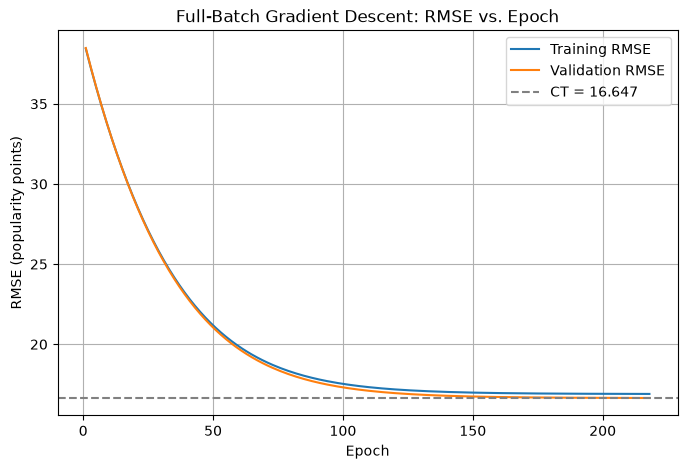

In [19]:
# YOUR CODE HERE
# Convert df to numpy arrays 
y_train = np.asarray(y_train, dtype=float)
y_val = np.asarray(y_val, dtype=float)

# Convergence threshold for gradient descent
rmse_direct = rmse_val
CT = 1.001 * rmse_direct

# Setup 
np.random.seed(10) # as per instructions
n, d = X_train.shape # get num. of samples and features
theta = np.random.rand(d) * 0.001 # each component is below 0.001
gamma = 0.01 # step size rate
max_epoch = 10000 # epoch limit (Question 4)

# Collect history of RMSE for plotting
train_rmse_history = []
val_rmse_history = []
converged = False # Check if CT is reached

# Gradient Descent Loop
start_time = time.time()

residuals = X_train @ theta - y_train # residuals using theta
for epoch in range(max_epoch):
    # Compute the gradient (Question 1)
    gradient = (2/n) * (X_train.T @ residuals) 
    theta = theta - gamma * gradient # update theta

    # Calculate Residuals and RMSE for training and validation sets
    residuals = X_train @ theta - y_train # update residuals
    train_rmse = np.sqrt(np.mean(residuals**2)) # RMSE for training set
    val_rmse = np.sqrt(np.mean((X_val @ theta - y_val)**2)) # RMSE for validation set

    # Append RMSE history for plotting
    train_rmse_history.append(train_rmse)
    val_rmse_history.append(val_rmse)

    # Stopping Rule where val_rmse < CT (Question 2)
    if val_rmse <= CT:
        converged = True
        # Print the epoch and validation RMSE @ convergence
        print(f"Converged at epoch {epoch+1}, validation RMSE: {val_rmse:.4f}")
        break

train_time = time.time() - start_time

# Reports for reaching CT or not (Question 2 & 4)
if converged: # If converged
    print(f"CT reached after {epoch+1} epochs in {train_time:.2f} seconds.")
else: # If not converged
    print(f"CT NOT reached within {max_epoch} epochs ({train_time:.2f} seconds).") # Report time taken to train
    print(f"Convergence Threshold (CT) = {CT:.4f}") # Convergence threshold value
    print(f"Final validation RMSE = {val_rmse_history[-1]:.4f}") # Final validation rmse value after training
    print(f"Final training RMSE = {train_rmse_history[-1]:.4f}") # Final training rmse value after training

# Plotting the training and validation RMSE vs. epochs (Question 3)
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(train_rmse_history) + 1), train_rmse_history, label="Training RMSE")
plt.plot(range(1, len(val_rmse_history) + 1), val_rmse_history, label="Validation RMSE")

plt.axhline(CT, color="gray", linestyle="--", label=f"CT = {CT:.3f}") # CT line

plt.xlabel("Epoch")
plt.ylabel("RMSE (popularity points)")
plt.title("Full-Batch Gradient Descent: RMSE vs. Epoch")

plt.legend()
plt.grid(True)
plt.show()

## Part 4 — Mini-Batch and Stochastic Gradient Descent [24 marks]

**Implementation note:** Implement the mini-batch/SGD updates, batching, shuffling, stopping rule, and history tracking yourself. Do not use a built-in optimizer.

**Goal:** Study how mini-batch size affects convergence speed and computational cost.

### 4.1 Implement mini-batch gradient descent **[10]**

Write a function that performs mini-batch gradient descent until CT is reached.

Your function should take as input:
- the training and validation data,
- the mini-batch size,
- the learning rate,
- CT.

It should return:
- the final weight vector,
- the training RMSE after each epoch,
- the validation RMSE after each epoch,
- the cumulative elapsed time after each epoch.

Use the following common iteration limit for every run in Part 4:

```python
PART4_MAX_EPOCHS = 200
```

Stop when CT is reached or when the epoch limit is reached. Record wall-clock time, but **do not use elapsed time as a stopping rule**; otherwise, convergence would depend on the speed of the student's computer.

Implementation rules:

- Set `np.random.seed(5)` before initializing the weights.
- After each epoch, shuffle the training observations while keeping the inputs and targets aligned. You may use `np.random.permutation`; for efficiency, you may shuffle an array of row indices rather than physically copying the full training matrix each epoch.
- Stop if the RMSE becomes non-finite or shows sustained divergence.
- Record whether CT was reached before the stopping limits.

### 4.2 Compare different batch sizes **[6]**

Use the learning rate \(0.0015\) and run the algorithm for exactly the following batch sizes:

$$
16,\;32,\;64,\;128,\;256,\;512,\;1024,\;2048.
$$

For each batch size, report:
- whether CT was reached,
- the number of epochs completed,
- the number of parameter updates per epoch,
- the total time to reach CT or to stop.

Use the same learning rate and maximum number of epochs for every batch size.

### 4.3 Visualize and compare convergence **[6]**

For the batch sizes that reach CT, produce the following two figures:

1. **Training and validation RMSE versus elapsed time.** **[4]**
2. **Total time to convergence versus batch size.** **[2]**

For Figure 1, use **multiple subplots** so the curves remain readable. Show at most **two batch sizes per subplot** (at most four RMSE curves: training and validation for each batch size). Use the **same axis limits across all subplots** so the batch sizes can be compared correctly.

Figure 2 should be shown as its own figure.

### 4.4 Interpretation **[2]**

Among the batch sizes that reach CT, which one reaches CT fastest in **wall-clock time**? Justify your answer using your table and convergence figure. **[2]**


In [21]:
PART4_MAX_EPOCHS = 200
PART4_BATCH_SIZES = [
    16, 32, 64, 128, 256, 512, 1024, 2048
]

def mini_batch_gd(
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size,
    learning_rate,
    CT,
    max_epochs=PART4_MAX_EPOCHS,
):
    # YOUR CODE HERE
    # Return weights, train_history, val_history, time_history

    # 4.1: Implement mini-batch gradient descent 

    # 1. Get all of the train and val data as numpy arrays
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    X_val = np.asarray(X_val, dtype=float)  
    y_val = np.asarray(y_val, dtype=float)

    # 2. Setup
    np.random.seed(5) # as per instructions
    n, d = X_train.shape # get num. of samples and features
    theta = np.random.rand(d) * 0.001 # each component is below 0.001

    # 3. Calculate RMSE (Made a function from Part 2)
    initial_val_rmse = calculate_rmse(y_val, X_val @ theta)

    # 4. Make lists to store train, val, and time history
    train_rmse_history = []
    val_rmse_history = []
    time_history = []

    # 5. Create copy variables for the shuffled x_train and y_train
    X_train_shuffled = X_train.copy()
    y_train_shuffled = y_train.copy()

    # 6. Start the timer (online recommended the perf_counter function)
    start_time = time.perf_counter()

    # 7. Loop through each epoch
    for epoch in range(max_epochs):
        # 7a. Slice into mini batches, compute the gradient, and update theta
        for i in range(0, n, batch_size):
            X_batch = X_train_shuffled[i:i + batch_size]
            y_batch = y_train_shuffled[i:i + batch_size]
            size = len(y_batch) # size of the current mini-batch
            gradient = (2/size) * (X_batch.T @ (X_batch @ theta - y_batch)) # compute gradient
            theta = theta - learning_rate * gradient # update theta / descent

        # 7b. Evaluate RMSE for training and validation sets and Record histories
        train_rmse = calculate_rmse(y_train, X_train @ theta)
        val_rmse = calculate_rmse(y_val, X_val @ theta)

        train_rmse_history.append(train_rmse)
        val_rmse_history.append(val_rmse)
        time_history.append(time.perf_counter() - start_time)

        # 7c. Check Stopping Conditions (Add console messages for each stopping condition so I know why it stops)
        # A. Convergence Threshold (CT) reached
        if val_rmse <= CT:
            print(f"CT reached at epoch {epoch+1}, validation RMSE: {val_rmse:.4f}")
            break
        # B. Non-infinite RMSE (NaN or Inf) reached
        if not np.isfinite(val_rmse) or not np.isfinite(train_rmse):
            print(f"Non-finite RMSE reached at epoch {epoch+1}, validation RMSE: {val_rmse:.4f}, training RMSE: {train_rmse:.4f}")
            break
        # C. Sustained Divergence (RMSE explodes or grows too large) 
        if val_rmse > 10 * initial_val_rmse:
            print(f"Sustained divergence reached at epoch {epoch+1}, validation RMSE: {val_rmse:.4f}, training RMSE: {train_rmse:.4f}")
            break

        # 7d. Shuffle the training data for the next epoch
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

    # 8. Return: Final weight vector (theta), Training RMSE history, Validation RMSE history, Time history
    return theta, train_rmse_history, val_rmse_history, time_history

In [ ]:
# 4.2 Compare differe Batch Sizes
# 1. Initializing varaibles
PART4_LEARNING_RATE = 0.0015
train_size = len(X_train)
runs, rows = {}, []

# 2. Loop through each batch size
for batch in PART4_BATCH_SIZES:
    # 2a. Run mini-batch gradient descent with the current batch size
    theta_b, train_history, val_history, time_history = mini_batch_gd(
        X_train, y_train, X_val, y_val, batch, PART4_LEARNING_RATE, CT, PART4_MAX_EPOCHS
    )

    # 2b. Find if CT was reached from the last validation RMSE in the history
    final_val_rmse = val_history[-1]
    reached = bool(np.isfinite(final_val_rmse) and final_val_rmse <= CT) 
    # True: CT reached, False: CT not reached

    # 2c. Store variable or stopping reason (personally want to know why)
    if reached:
        stop_reason = "CT reached"
    elif not np.isfinite(final_val_rmse):
        stop_reason = "Non-finite RMSE"
    elif len(val_history) >= PART4_MAX_EPOCHS:
        stop_reason = "Max epochs reached"
    else:
        stop_reason = "Sustained divergence"

    # 2d. Save runs in a dictionary for 4.3 (batch: {theta, train_history, val_history, time_history, stop_reason})
    runs[batch] = dict(theta=theta_b, train_history=train_history, val_history=val_history, 
                           time_history=time_history, stop_reason=stop_reason)

    # 2e. Append the results to rows for the final report
    # I added a few things like final validaton RMSE and a reason for stopping to the final report
    rows.append({
        "batch_size": batch,
        "reached_CT": reached, 
        "epochs_completed": len(val_history),
        "updates_per_epoch": int(np.ceil(train_size / batch)),
        "total_time_s": round(time_history[-1], 3),
        "final_val_RMSE": round(val_history[-1], 4), # Final validation RMSE after training (for min/max y-axis in plots)
        "stop_reason": stop_reason, # Want to add a reason for stopping to the final report
    })

# 3. Create a DataFrame to display the results
results_df = pd.DataFrame(rows)

# 4. Print the results
print(f"\nCT = {CT:.4f} | Learning Rate = {PART4_LEARNING_RATE} | Max Epochs = {PART4_MAX_EPOCHS}")
print(results_df.to_string(index=False))


CT reached at epoch 17, validation RMSE: 16.6396
CT reached at epoch 3, validation RMSE: 16.6389
CT reached at epoch 3, validation RMSE: 16.6462
CT reached at epoch 6, validation RMSE: 16.6448
CT reached at epoch 12, validation RMSE: 16.6455
CT reached at epoch 24, validation RMSE: 16.6453
CT reached at epoch 47, validation RMSE: 16.6462

CT = 16.6465 | Learning Rate = 0.0015 | Max Epochs = 200
 batch_size  reached_CT  epochs_completed  updates_per_epoch  total_time_s  final_val_RMSE        stop_reason
         16       False               200               4000        33.290         16.7119 Max epochs reached
         32        True                17               2000         2.680         16.6396         CT reached
         64        True                 3               1000         0.401         16.6389         CT reached
        128        True                 3                500         0.302         16.6462         CT reached
        256        True                 6           

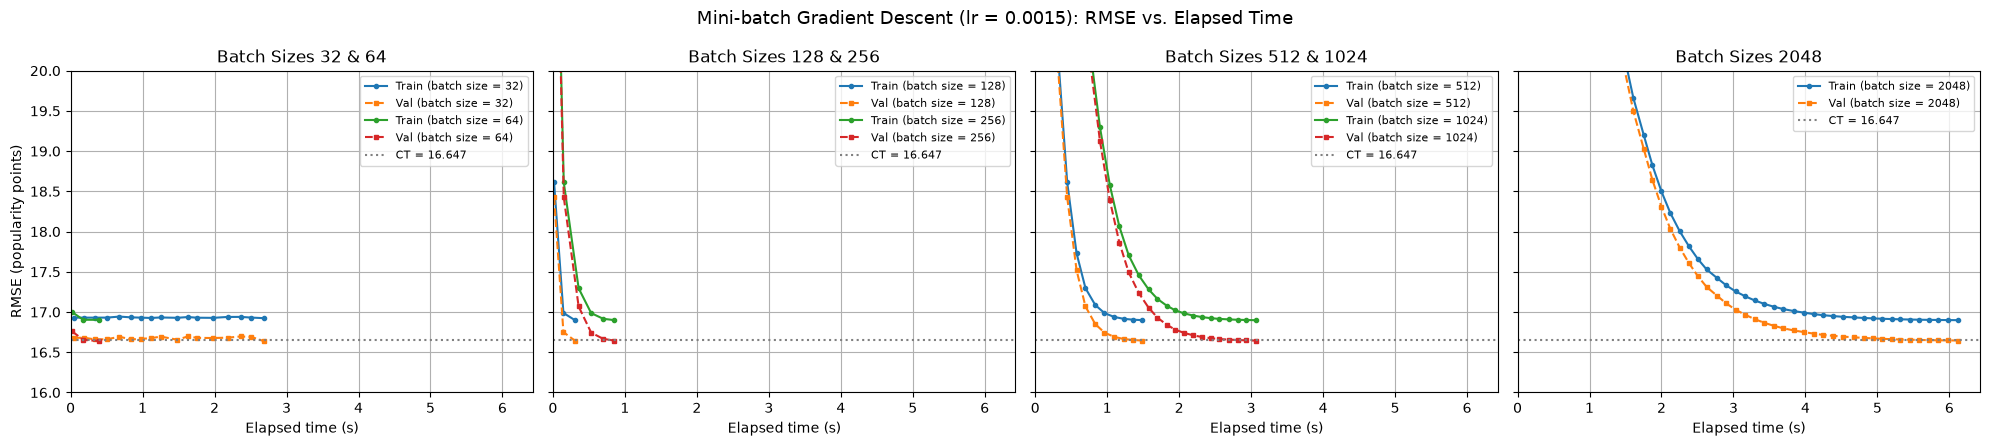

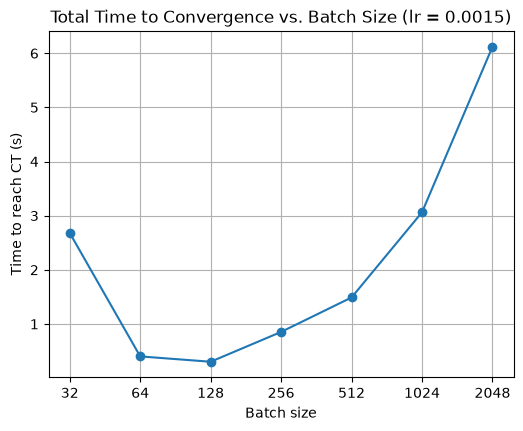

In [ ]:
# Use exactly the batch sizes in PART4_BATCH_SIZES.

# For the RMSE-vs-time figure:
# - use multiple subplots,
# - show at most two batch sizes per subplot,
# - keep common axis limits across all subplots.

# Plot total time to convergence versus batch size in a separate figure.

# YOUR CODE HERE: batch-size sweep, results table, and the two required figures.

# 4.3 Visualize and Compare Convergence
# Identify which batch sizes converged (CT reached) and which did not.
# Remember the runs dictionary contains -> batch: {theta, train_history, val_history, time_history, stop_reason}
converged_bs = [b for b in PART4_BATCH_SIZES if runs[b]["stop_reason"] == "CT reached"]

# Figure 1: Training and Validation RMSE vs. Elapsed Time (for each batch size)
# At most two batch sizes per subplot
pair_plot = [converged_bs[i:i + 2] for i in range(0, len(converged_bs), 2)]

# Adding the axis limits across all subplots (for consistency)
x_max = max(runs[b]["time_history"][-1] for b in converged_bs) * 1.05 # 5% more than max time
y_min = 16 # Know because of the table of results I made in 4.2 (final_val_RMSE column)
y_max = 20 # Changed to 20 so it's easier to see the plot
# y_max = max(runs[b]["val_history"][0] for b in converged_bs) * 1.05 # 5% more than max initial validation RMSE

# Configure the subplots
fig, axes = plt.subplots(1, len(pair_plot), figsize=(5 * len(pair_plot), 4.5),
                         sharex=True, sharey=True, squeeze=False)

# Run plots
for ax, pair in zip(axes[0], pair_plot):
    for b in pair:
        ax.plot(runs[b]["time_history"], runs[b]["train_history"], marker="o", markersize=3,
                label=f"Train (batch size = {b})")
        ax.plot(runs[b]["time_history"], runs[b]["val_history"], marker="s", markersize=3,
                linestyle="--", label=f"Val (batch size = {b})")
    ax.axhline(CT, color="gray", linestyle=":", label=f"CT = {CT:.3f}")
    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_title("Batch Sizes " + " & ".join(str(b) for b in pair))
    ax.grid(True)
    ax.legend(fontsize=8)

# Show the plots
axes[0][0].set_ylabel("RMSE (popularity points)")
fig.suptitle(f"Mini-batch Gradient Descent (lr = {PART4_LEARNING_RATE}): RMSE vs. Elapsed Time", fontsize=13)
plt.tight_layout()
plt.show()



# Figure 2: Total Time to Convergence vs. Batch Size (16 not shown since it did not converge)
plt.figure(figsize=(6, 4.5))
plt.plot(converged_bs, [runs[b]["time_history"][-1] for b in converged_bs], marker="o")
plt.xscale("log", base=2)
plt.xticks(converged_bs, [str(b) for b in converged_bs])
plt.xlabel("Batch size")
plt.ylabel("Time to reach CT (s)")
plt.title(f"Total Time to Convergence vs. Batch Size (lr = {PART4_LEARNING_RATE})")
plt.grid(True)
plt.show()

In [27]:
"""
4.4 Interpretation (Among the batch sizes that converged, which one reaches CT fastest in wall-clock time?)
Among the batch sizes that reached the convergence threshold (CT), the batch size of 128 reached CT the fastest wall-clock time 
of 0.302 seconds (3 epochs and 500 updates per epoch). The next best was batch size 64 at 0.401 seconds, and the slowest was 
2048 at 6.119 seconds.

From observing the table from 4.2 and figures from 4.3:
- Small Batch Sizes (16, 32): Each update uses very few samples, so the gradient is noisy and the weights bounce around the minimum 
instead of settling. Batch size 32 needed 17 epochs (about 34,000 updates, 2000 per epoch) and 2.680 seconds to reach CT. Batch size 16 
did not reach CT at all in 200 epochs (final validation RMSE 16.7119 and is above CT = 16.6465).
- Large Batch Sizes (256, 512, 1024, 2048): The RMSE is smoother and more stable, but there are fewer updates per epoch, so the model 
needs more epochs to make the same progress. Look at batch size 2048 for example: It has only 32 updates per epoch, so it took 47 epochs 
and 6.119 seconds to reach CT.
- Medium Batch Sizes (64, 128): These batch sizes seem to balance number of updates and time per epoch. Both of these graphs show a
smooth RMSE curve and reach CT in a reasonable amount of time as batch size of 64 took 3 epochs (1000 updates per epoch) and 0.401 
seconds to reach CT, while batch size of 128 took 3 epochs (500 updates per epoch) and 0.302 seconds to reach CT.

By strictly looking at the figures:
- Figure 1: Batch size 128 shows the curves crossing the CT line first
- Figure 2: Batch size 128 shows the lowest time to reach CT
"""

'\n4.4 Interpretation (Among the batch sizes that converged, which one reaches CT fastest in wall-clock time?)\nAmong the batch sizes that reached the convergence threshold (CT), the batch size of 128 reached CT the fastest wall-clock time \nof 0.302 seconds (3 epochs and 500 updates per epoch). The next best was batch size 64 at 0.401 seconds, and the slowest was \n2048 at 6.119 seconds.\n\nFrom observing the table from 4.2 and figures from 4.3:\n- Small Batch Sizes (16, 32): Each update uses very few samples, so the gradient is noisy and the weights bounce around the minimum \ninstead of settling. Batch size 32 needed 17 epochs (about 34,000 updates, 2000 per epoch) and 2.680 seconds to reach CT. Batch size 16 \ndid not reach CT at all in 200 epochs (final validation RMSE 16.7119 and is above CT = 16.6465).\n- Large Batch Sizes (256, 512, 1024, 2048): The RMSE is smoother and more stable, but there are fewer updates per epoch, so the model \nneeds more epochs to make the same progres

## Part 5 — Choosing the Learning Rate [20 marks]

**Implementation note:** All learning-rate experiments must use your own mini-batch gradient-descent implementation from Part 4; do not replace it with a library optimizer.

**Goal:** Investigate how the choice of learning rate affects the convergence of mini-batch gradient descent.

In Part 4, the same learning rate was used for different batch sizes. In this part, you will tune the learning rate empirically and study how sensitive convergence is to this choice.

For all runs in Part 5, use

```python
PART5_MAX_EPOCHS = 200
```

as the common stopping budget. Record elapsed time, but **do not stop based on wall-clock time**.

### 5.1 Empirical learning-rate search **[5]**

Select the first three batch sizes that did not converge in Part 4. For each batch size, try the following learning rates **in order**:

$$
0.01,\;0.005,\;0.002,\;0.001,\;0.0005.
$$

Stop testing learning rates for that batch size as soon as one reaches CT.

Report the following in a table:
- batch size,
- first learning rate that reaches CT,
- training RMSE at convergence,
- validation RMSE at convergence,
- time to reach CT.

If none of the five learning rates reaches CT within 200 epochs, report that no candidate converged. If fewer than three batch sizes failed in Part 4, use the failed cases available and complete the three cases using other tested batch sizes.

### 5.2 Sensitivity to the learning rate **[10]**

Choose the batch size with the fastest convergence time in Part 4. Test exactly **eight learning rates** spanning

$$
5\times10^{-4}
\quad\text{to}\quad
2\times10^{-2}.
$$

The learning rates do **not** all need to reach CT; failed or unstable runs are part of the comparison.

**Plotting note:** Do not overload a single figure with too many curves. Use multiple subplots or separate figures so the learning-rate comparisons remain readable. A good choice is **one learning rate per subplot**, showing only its training and validation curves.

1. Plot training and validation RMSE versus epoch for the eight learning rates. **[4]**
2. Plot training and validation RMSE versus elapsed time. **[4]**
3. Among the learning rates that reach CT, identify the one that reaches it fastest. **[2]**

### 5.3 Interpretation **[5]**

Answer the following questions based on your results from **Part 4, Section 5.1, and Section 5.2**.

1. How does the successful learning rate found in Section 5.1 change across the batch sizes you tested? Do larger batch sizes appear to tolerate larger or smaller learning rates? **[2]**

2. Using the learning-rate experiment from Section 5.2, explain what happens when the learning rate is too small and what happens when it becomes too large. Relate this to the convergence speed you observed. **[2]**

3. What statistical property of the **stochastic gradient estimator** explains why the appropriate learning rate depends on batch size? Briefly explain how this property changes as batch size increases. **[1]**

   **Hint:** Use the theoretical SGD convergence guarantee to explain why this statistical property affects the choice of learning rate.


# Case Study B — California Housing
## Part 6 — Independent Regression Study [17 marks]

**Goal:** Transfer the regression workflow to a new dataset and use standard `sklearn` tools to compare linear regression, polynomial features, and ridge regularization.

This section is independent of Parts 1–5 and uses the California Housing dataset. The supplied starter code downloads a CSV copy directly, avoiding dependence on scikit-learn's remote dataset server.

The dataset contains **8 quantitative predictors** describing California housing districts. The target, `MedHouseVal`, is median house value measured in units of **$100,000**.

You may use the relevant built-in `sklearn` utilities.

### 6.1 Data preparation **[2]**

- Run the supplied starter code to download and load the California Housing dataset, and display the resulting dataframe.
- Create NumPy arrays for inputs `X` and targets `y`.
- Split the data into **80% training / 20% validation** using `random_state=5`.

### 6.2 Linear regression **[3]**

- Standardize the predictors using `StandardScaler`.
- Fit `sklearn.linear_model.LinearRegression`.
- Report training and validation RMSE.

### 6.3 Linear regression with additional features **[4]**

- Starting from the **unstandardized** predictors, create degree-5 polynomial features with `sklearn.preprocessing.PolynomialFeatures`.
- Standardize the expanded feature matrix.
- Fit `LinearRegression` again.
- Report training and validation RMSE.

### 6.4 Polynomial features + ridge regularization **[5]**

- Fit `sklearn.linear_model.Ridge` using the expanded, standardized predictors from Section 6.3.
- Sweep `alpha` from `1E-2` to `1E10`, increasing by one order of magnitude at each step.
- Record the training and validation RMSE for every value.

### 6.5 Model comparison and conclusion **[3]**

Compare:

1. simple linear regression,
2. degree-5 polynomial regression,
3. polynomial regression with ridge regularization.

Discuss how feature expansion and regularization change **training error**, **validation error**, and **overfitting**. Select the model with the strongest validation performance without unnecessary complexity.

### About the California Housing starter code

Run the common **Setup** cell near the beginning of the notebook before running the code below. Setup imports Pandas and defines `download_dataset`.

The supplied code prepares the dataset for Part 6:

1. **Download the data.** `CALIFORNIA_HOUSING_URL` gives the CSV file's location. `download_dataset` saves it in the notebook's `data` folder and reuses the local file if it already exists. `california_path` stores the path to that file. An internet connection is needed for the first download.
2. **Load and preview the table.** `pd.read_csv(california_path)` loads the CSV into the DataFrame `df2`. `display(df2.head())` shows its first five rows so you can inspect the column names and example values; the full dataset remains in `df2`.
3. **Identify the inputs.** `HOUSING_FEATURES` lists the eight predictor columns. Each row describes a housing district rather than an individual house:

   | Column | Meaning |
   |---|---|
   | `MedInc` | Median income in the district |
   | `HouseAge` | Median house age in the district |
   | `AveRooms` | Average number of rooms per household |
   | `AveBedrms` | Average number of bedrooms per household |
   | `Population` | District population |
   | `AveOccup` | Average number of people per household |
   | `Latitude` | District latitude |
   | `Longitude` | District longitude |

4. **Identify the target.** `HOUSING_TARGET` is the column name `MedHouseVal`, the district's median house value in units of **$100,000**. For example, a target value of `2.5` represents $250,000. An RMSE of `0.5` corresponds to $50,000 in root-mean-square prediction error.

**Your work begins in the next code cell, after the supplied starter code.** Use `df2[HOUSING_FEATURES]` to select the input columns and `df2[HOUSING_TARGET]` to select the target, then convert them to NumPy arrays. Complete Sections **6.1–6.5**: split the data, fit the three types of regression model, report training and validation RMSE, and explain the comparison. The starter code only loads the data and names the columns; it does not split, standardize, or fit a model.

Use the same training/validation split for all three model comparisons. Fit each scaler on the **training data only**, then use that fitted scaler to transform the validation data. For the polynomial models, build the polynomial features from the unstandardized inputs before standardizing the expanded features, as requested in Section 6.3.


In [ ]:
CALIFORNIA_HOUSING_URL = (
    "https://huggingface.co/datasets/BIT/california_housing/resolve/main/california_housing.csv"
)

california_path = download_dataset(
    CALIFORNIA_HOUSING_URL,
    "california_housing.csv",
)

df2 = pd.read_csv(california_path)
display(df2.head())

HOUSING_FEATURES = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
]
HOUSING_TARGET = "MedHouseVal"


In [ ]:
### YOUR CODE HERE ###


## Optional Mathematical Question — The Law of Large Numbers Does Not Imply Uniform Convergence [10 bonus marks]

For a fixed model, the **Law of Large Numbers (LLN)** says that its empirical risk approaches its population risk as the sample size grows.

A hypothesis class \(\mathcal H\) has **uniform convergence** if, for every \(\epsilon>0\) and \(\delta>0\), there is a sufficiently large sample size \(n\) such that, with probability at least \(1-\delta\),

$$
\sup_{h\in\mathcal H}
\left|
\widehat R_n(h)-R(h)
\right|
\le \epsilon.
$$

Equivalently, for every \(\epsilon>0\),

$$
\Pr\!\left(
\sup_{h\in\mathcal H}
\left|
\widehat R_n(h)-R(h)
\right|
>\epsilon
\right)
\to0
\qquad\text{as }n\to\infty.
$$

Here, the probability is over the random training sample. \(R(h)\) is the expected loss on a new observation, \(\widehat R_n(h)\) is the average training loss, and the supremum is the largest gap over all hypotheses in \(\mathcal H\).

In this part, we will show that convergence for every fixed hypothesis does **not** necessarily imply uniform convergence over the whole class.

Let

$$
X\sim\mathrm{Unif}[0,1],
\qquad
Y=0,
$$

and use squared loss,

$$
\ell(\hat y,y)=(\hat y-y)^2.
$$

For every finite set \(A\subset[0,1]\), define

$$
h_A(x)=
\begin{cases}
0, & x\in A,\\
1, & x\notin A.
\end{cases}
$$

Thus, \(h_A\) predicts 0 on the finite set \(A\) and 1 everywhere else. Let

$$
\mathcal H
=
\{h_A:A\subset[0,1]\text{ is finite}\}.
$$

For an i.i.d. training sample

$$
D_n=\{(X_1,Y_1),\ldots,(X_n,Y_n)\},
$$

define

$$
R(h)=\mathbb E[(h(X)-Y)^2],
\qquad
\widehat R_n(h)
=
\frac1n\sum_{i=1}^n(h(X_i)-Y_i)^2.
$$

### (a) Fixed hypothesis **[2 bonus marks]**

Fix \(h_A\in\mathcal H\), with \(A\) chosen independently of the sample.

1. Compute \(R(h_A)\). **[0.5]**
2. Use the LLN to show that \(\widehat R_n(h_A)\to R(h_A)\) almost surely. **[1]**
3. Conclude that for every fixed \(h\in\mathcal H\), **[0.5]**

$$
|\widehat R_n(h)-R(h)|\to0.
$$

### (b) Choose the hypothesis after seeing the sample **[4 bonus marks]**

For an arbitrary observed set of training inputs \(X_1,\ldots,X_n\), find a hypothesis \(h_A\in\mathcal H\) that maximizes **[1]**

$$
\left|
\widehat R_n(h_A)-R(h_A)
\right|.
$$

What is the maximum value of this gap? **[1]**

For any \(0<\epsilon<1\), determine

$$
\Pr\!\left(
\sup_{h\in\mathcal H}
\left|
\widehat R_n(h)-R(h)
\right|
>\epsilon
\right),
$$

and state what happens to this probability as \(n\to\infty\). **[2]**

### (c) A simpler infinite hypothesis class **[3 bonus marks]**

Now restrict the class so that \(A\) must be a single interval \(I=[a,b]\subseteq[0,1]\). Let

$$
\mathcal H_{\mathrm{int}}
=
\{h_I:I=[a,b]\subseteq[0,1]\}.
$$

Examine whether \(\mathcal H_{\mathrm{int}}\) satisfies the probabilistic definition of uniform convergence given above. Justify your answer, and briefly explain why the answer differs from the original class even though both classes are infinite. **[3]**

### (d) What does this teach us about choosing a hypothesis class? **[1 bonus mark]**

What does this example teach us about choosing a hypothesis class? Explain the trade-off between fitting the data and avoiding memorization. **[1]**
